In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [5]:
df = pd.read_csv('wine_data.csv',header=None , usecols=[0,1,2])
df.columns=['class label' , 'Alcohol' , 'Malic acid']

In [6]:
df

,class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

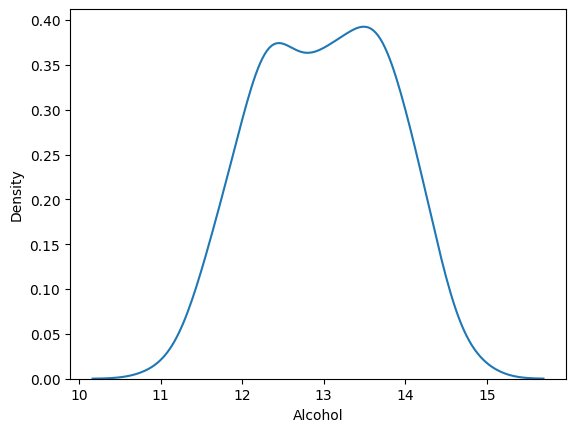

In [7]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

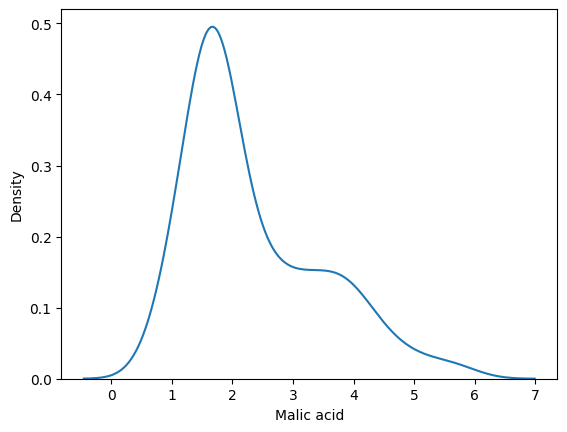

In [8]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

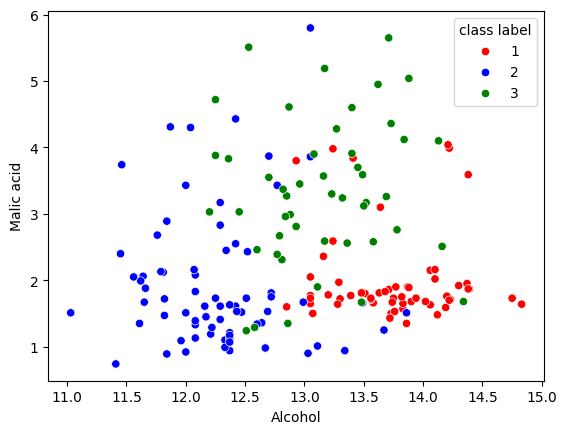

In [22]:
sns.scatterplot(x=df['Alcohol'] , y=df['Malic acid'] , hue=df['class label'] , palette=['red' , 'blue' , 'green'])

In [27]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   --------- ------------------------------ 1.8/8.0 MB 6.3 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.0 MB 8.9 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 8.8 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 8.4 MB/s  0:00:01

  Attempting uninstall: joblib

    Found existing installation: joblib 1.1.1

   ------------- -------------------------- 1/3 [joblib]
    Uninstalling joblib-1.1.1:
   ------------- -------------------------- 1/3 [joblib]
      Successfully uninstalled joblib-1.1.1


In [32]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(df.drop('class label' , axis=1) ,
                                                       df['class label'] , test_size = 0.3 , random_state=0)

In [33]:
x_train

,Alcohol,Malic acid
22,13.71,1.86
108,12.22,1.29
175,13.27,4.28
145,13.16,3.57
71,13.86,1.51
...,...,...
103,11.82,1.72
67,12.37,1.17
117,12.42,1.61
47,13.90,1.68


In [37]:
pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [42]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

#fit the scaler to train set , it will learn the paramter
#this means that model will learn all paramtr mean , median , SD , etc about the data

scaler.fit(x_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [44]:
#tranform train and test set
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# tranform data set to numpy array so again we have to transfer it to dataframe

In [45]:
x_train_scaled


array([[0.72043011, 0.20378151],
       [0.31989247, 0.08403361],
       [0.60215054, 0.71218487],
       [0.57258065, 0.56302521],
       [0.76075269, 0.1302521 ],
       [0.48924731, 0.5       ],
       [0.75537634, 0.67857143],
       [0.61021505, 0.17436975],
       [0.54301075, 0.62394958],
       [0.39784946, 0.07352941],
       [0.33870968, 0.1092437 ],
       [0.46774194, 0.53361345],
       [0.5188172 , 0.53781513],
       [0.70967742, 0.07563025],
       [0.57258065, 0.30882353],
       [0.36021505, 0.0105042 ],
       [0.38709677, 0.13235294],
       [0.20967742, 0.25840336],
       [0.59408602, 0.64915966],
       [0.82526882, 0.26680672],
       [0.15591398, 0.09663866],
       [0.52688172, 0.16386555],
       [0.46774194, 0.31512605],
       [0.65860215, 0.16386555],
       [0.1155914 , 0.5987395 ],
       [0.27956989, 0.26680672],
       [0.21236559, 0.12184874],
       [0.65053763, 0.59033613],
       [0.31451613, 0.44957983],
       [0.54301075, 0.17647059],
       [0.

In [48]:
x_train_scaled = pd.DataFrame(x_train_scaled , columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled , columns = x_test.columns)

In [49]:
x_train_scaled

# this again changed to data frame

,Alcohol,Malic acid
0,0.720430,0.203782
1,0.319892,0.084034
2,0.602151,0.712185
3,0.572581,0.563025
4,0.760753,0.130252
...,...,...
119,0.212366,0.174370
120,0.360215,0.058824
121,0.373656,0.151261
122,0.771505,0.165966


In [54]:
np.round(x_train.describe() , 1) ## 1 specify how many decimal places you want in this output

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


# 🧩 Step-by-Step Explanation

## 🔹 Step 1: Import plotting libraries

```python
import matplotlib.pyplot as plt
import seaborn as sns
```

- **matplotlib.pyplot** → basic plotting engine
- **seaborn** → makes plots prettier and easier
- Seaborn internally uses matplotlib.

---

## 🔹 Step 2: Define color palette

```python
c = ['red', 'blue', 'green']
```

- You have **3 classes** in your target
- Each class will get one **fixed color**
- Ensures **consistency** between plots

---

## 🔹 Step 3: Create two plotting areas

```python
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
```

**What this does:**
- Creates **1 row** and **2 columns** of plots
- `fig` → whole figure (container)
- `axes` → array of axes:
  - `axes[0]` → left plot
  - `axes[1]` → right plot

📌 **Without this, plots would overlap.**

---

## 🔹 Step 4: Plot AFTER scaling

```python
sns.scatterplot(
    x=x_train_scaled['Alcohol'],
    y=x_train_scaled['Malic acid'],
    hue=y_train,
    palette=c,
    ax=axes[0]
)
```

**Explanation of each argument:**

| Parameter | Meaning |
|-----------|---------|
| `x=` | X-axis feature (scaled Alcohol) |
| `y=` | Y-axis feature (scaled Malic acid) |
| `hue=` | Colors points by class label |
| `palette=` | Colors used for classes |
| `ax=` | Draw this plot on LEFT axis |

📌 **This plot shows how data looks after scaling.**

---

## 🔹 Step 5: Set title for first plot

```python
axes[0].set_title('After Scaling')
```

- Sets title **only for left plot**
- Cleaner than `plt.title()` in multi-plots

---

## 🔹 Step 6: Plot BEFORE scaling

```python
sns.scatterplot(
    x=x_train['Alcohol'],
    y=x_train['Malic acid'],
    hue=y_train,
    palette=c,
    ax=axes[1]
)
```

**Same idea as before, but:**
- Uses **original (unscaled)** data
- Drawn on **right plot**

📌 **This lets you visually compare scaling effect.**

---

## 🔹 Step 7: Set title for second plot

```python
axes[1].set_title('Before Scaling')
```

---

## 🔹 Step 8: Adjust spacing automatically

```python
plt.tight_layout()
```

- Prevents label/title overlap
- Makes plots look neat

---

## 🔹 Step 9: Display the plots

```python
plt.show()
```

- Renders everything on screen
- Mandatory in scripts & notebooks

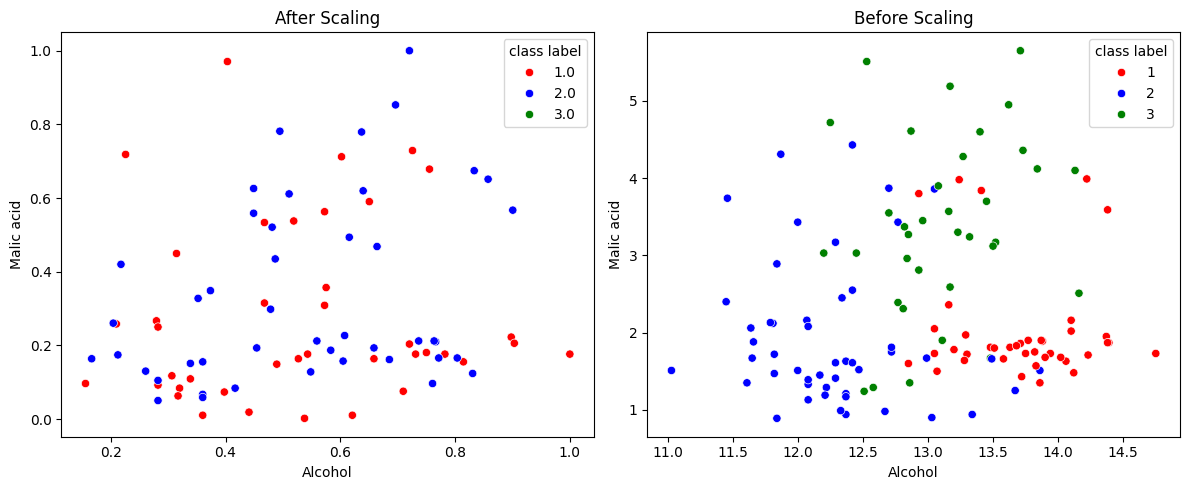

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

c = ['red', 'blue', 'green']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    x=x_train_scaled['Alcohol'],
    y=x_train_scaled['Malic acid'],
    hue=y_train, ## output class label
    palette=c,
    ax=axes[0]
)
axes[0].set_title('After Scaling')

sns.scatterplot(
    x=x_train['Alcohol'],
    y=x_train['Malic acid'],
    hue=y_train,
    palette=c,
    ax=axes[1]
)
axes[1].set_title('Before Scaling')

plt.tight_layout()
plt.show()


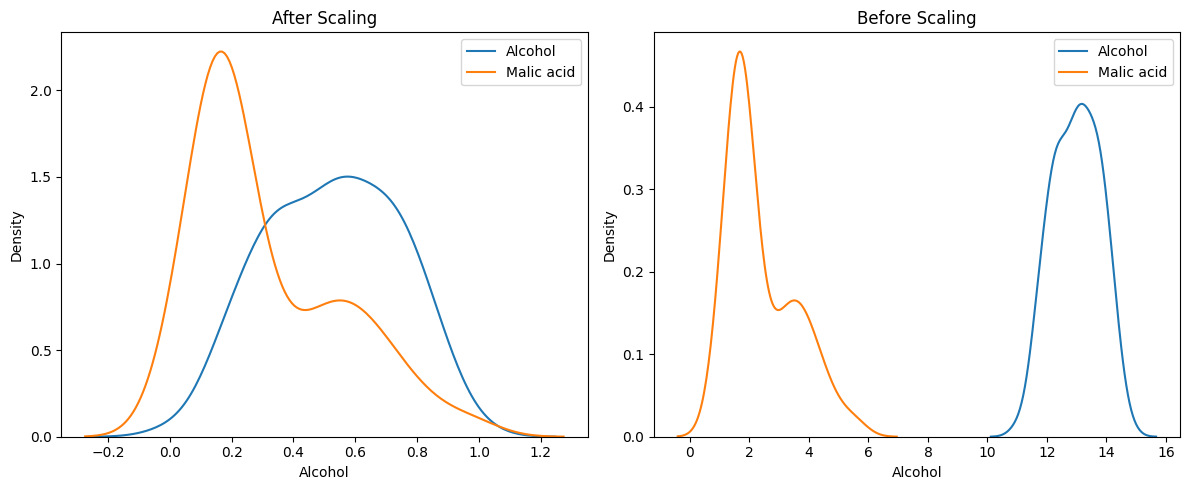

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------- After Scaling --------
sns.kdeplot(x=x_train_scaled['Alcohol'], ax=axes[0], label='Alcohol')
sns.kdeplot(x=x_train_scaled['Malic acid'], ax=axes[0], label='Malic acid')
axes[0].set_title('After Scaling')
axes[0].legend()

# -------- Before Scaling --------
sns.kdeplot(x=x_train['Alcohol'], ax=axes[1], label='Alcohol')
sns.kdeplot(x=x_train['Malic acid'], ax=axes[1], label='Malic acid')
axes[1].set_title('Before Scaling')
axes[1].legend()

plt.tight_layout()
plt.show()
